# Диагностика скорости доставки `t_available`

## Назначение

событийная модель DiD для временной метрики `t_available` на финальной DiD-выборке; проверка пред-трендов по CORE-типам изменений.

## Входные данные

Финальная выборка через тот же пайплайн, что в `final_empirical_recalculation.ipynb` (`min_orders_per_hex=5`, исключение когорты `2022-10-19`).

## Результаты

Таблица `speed_did_summary_revised.csv`, событийная модель графики в `figures/empirical/`.

## Статус

Вспомогательный диагностический ноутбук; результаты по скорости не включены в основные каузальные таблицы при значимых pretrends.


Этот ноутбук заменяет старую версию `speed_did_extension.ipynb`.
Что исправлено:
1. Ноутбук больше не запускает `%run ./preestimationDID.ipynb`, потому что старый предоценочный ноутбук строит более широкую диагностическую выборку и не совпадает с финальной DiD-выборкой.
2. Используется тот же финальный пайплайн, что и в `final_empirical_recalculation.ipynb`: окно исследования до `2022-10-18`, исключение когорты `2022-10-19`, порог `min_orders_per_hex=5`.
3. Анализ ограничен только тремя CORE-типами изменений: `region_and_workmode`, `region_only`, `workmode_only`.
4. `t_available` агрегируется на уровень `hex × day` медианой, а не средним. Для временных метрик это устойчивее к выбросам.
5. Результаты по скорости автоматически помечаются как каузально интерпретируемые только если тест предтрендов не отвергает параллельные тренды.
Если предтренды для `t_available` значимы, этот блок нужно оставлять как диагностический, а не как основной причинный результат.


In [1]:
# ============================================================
# 0. Настройки путей
# ============================================================

from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

cwd = Path.cwd().resolve()
if cwd.name.lower() in {"notebooks", "notebook"}:
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

# При необходимости путь задаётся явно:
# PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
APPLICATIONS_PATH = DATA_RAW / "application_dataset.csv"
HEXAGONS_PATH = DATA_RAW / "hexagons_dataset.csv"

FIG_DIR = PROJECT_ROOT / "figures" / "empirical"
OUT_DIR = PROJECT_ROOT / "outputs" / "empirical"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("APPLICATIONS_PATH:", APPLICATIONS_PATH)
print("HEXAGONS_PATH:", HEXAGONS_PATH)
print("FIG_DIR:", FIG_DIR)
print("OUT_DIR:", OUT_DIR)

assert APPLICATIONS_PATH.exists(), f"Не найден файл: {APPLICATIONS_PATH}"
assert HEXAGONS_PATH.exists(), f"Не найден файл: {HEXAGONS_PATH}"


PROJECT_ROOT: <resolved relative to repository root>
APPLICATIONS_PATH: <under repository root>
HEXAGONS_PATH: <under repository root>
FIG_DIR: <under repository root>
OUT_DIR: <under repository root>


In [2]:
# ============================================================
# 1. Импорты и подключение финального пайплайна
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

candidate_paths = [
    PROJECT_ROOT,
    PROJECT_ROOT / "last_mile",
    PROJECT_ROOT / "src",
    Path.cwd(),
    Path.cwd().parent,
]
for p in candidate_paths:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

try:
    from last_mile.filter import build_analysis_panel, CORE_CHANGE_TYPES
except Exception:
    from filter import build_analysis_panel, CORE_CHANGE_TYPES

try:
    from linearmodels.panel import PanelOLS
except ImportError as e:
    raise ImportError(
        "Не установлен пакет linearmodels. Установи его командой: "
        "!pip install linearmodels"
    ) from e

TYPE_ORDER = ["region_and_workmode", "region_only", "workmode_only"]
assert set(TYPE_ORDER) == set(CORE_CHANGE_TYPES), (
    "TYPE_ORDER должен совпадать с CORE_CHANGE_TYPES. "
    f"TYPE_ORDER={TYPE_ORDER}, CORE_CHANGE_TYPES={CORE_CHANGE_TYPES}"
)

TYPE_LABELS = {
    "region_and_workmode": "Смена региона и режима",
    "region_only": "Только смена региона",
    "workmode_only": "Только смена режима работы",
}

SPEED_OUTCOME = "t_available"
TIME_OUTCOMES = {"t_available", "t_utilization"}

print("CORE_CHANGE_TYPES:", CORE_CHANGE_TYPES)


CORE_CHANGE_TYPES: ['region_only', 'workmode_only', 'region_and_workmode']


In [3]:
# ============================================================
# 2. Финальная аналитическая выборка
# ============================================================

result = build_analysis_panel(
    applications_path=APPLICATIONS_PATH,
    hexagons_path=HEXAGONS_PATH,
    min_orders_per_hex=5,
)

panel = result["panel"].copy()
apps_t = result["treated_orders"].copy()
apps_c = result["control_orders"].copy()
cohort_map = result["cohort_map"].copy()

# Единые имена колонок для дальнейшего кода.
for df in (apps_t, apps_c):
    if "cohort" in df.columns and "treatment_date" not in df.columns:
        df["treatment_date"] = df["cohort"]
    if "date" not in df.columns:
        df["date"] = df["request_timestamp"].dt.normalize()

if "days_from_treatment" not in apps_t.columns:
    apps_t["days_from_treatment"] = (
        apps_t["request_timestamp"] - apps_t["treatment_date"]
    ).dt.days

OBS_MIN = min(apps_t["request_timestamp"].min(), apps_c["request_timestamp"].min())
OBS_MAX = max(apps_t["request_timestamp"].max(), apps_c["request_timestamp"].max())

summary_panel = pd.DataFrame({
    "Показатель": [
        "Начало периода наблюдений",
        "Конец периода наблюдений",
        "Наблюдений уровня hex-day",
        "Гексагонов в панели",
        "Treated-гексагонов",
        "Never-treated гексагонов",
        "Treated-заявок",
        "Control-заявок",
        "Минимальный порог заявок на гексагон",
    ],
    "Значение": [
        str(panel["date"].min().date()),
        str(panel["date"].max().date()),
        len(panel),
        panel["hex"].nunique(),
        panel.loc[panel["is_treated"], "hex"].nunique(),
        panel.loc[~panel["is_treated"], "hex"].nunique(),
        len(apps_t),
        len(apps_c),
        5,
    ],
})

display(summary_panel)

print("OBS_MIN:", OBS_MIN)
print("OBS_MAX:", OBS_MAX)
print("t_available non-null treated:", apps_t[SPEED_OUTCOME].notna().sum())
print("t_available non-null control:", apps_c[SPEED_OUTCOME].notna().sum())


[INFO] attach_hex_metadata: отброшено 6 заявок из гексагонов, не представленных в hexagons_dataset.
[INFO] exclude_cohorts: исключено 683162 заявок из когорт ['2022-10-19'].
[INFO] build_analysis_panel: после порогового фильтра (≥5 заявок) осталось 13256 уникальных гексагонов.

СВОДКА АНАЛИТИЧЕСКОЙ ПАНЕЛИ
  Период:              2022-04-01 - 2022-10-18
  Наблюдений (hex×day):   302,403
  Гексагонов всего:        13,256
  - трактуемых:             9,328
  - never-treated:          3,928

  Когорты (включённые):
    2022-07-27  →  437 гексагонов
    2022-08-12  →  1358 гексагонов
    2022-08-19  →  2723 гексагонов
    2022-09-22  →  4810 гексагонов

  Исключённые когорты: ['2022-10-19']



                             Показатель    Значение
0             Начало периода наблюдений  2022-04-01
1              Конец периода наблюдений  2022-10-18
2             Наблюдений уровня hex-day      302403
3                   Гексагонов в панели       13256
4                    Treated-гексагонов        9328
5              Never-treated гексагонов        3928
6                        Treated-заявок      781380
7                        Control-заявок      323125
8  Минимальный порог заявок на гексагон           5

OBS_MIN: 2022-04-01 00:00:00
OBS_MAX: 2022-10-18 00:00:00
t_available non-null treated: 732870
t_available non-null control: 301897


## 3. Проверка состава CORE-когорт для скорости

Для `t_available` используем тот же набор CORE-когорт, что и для `sch_flg`: `2022-07-27`, `2022-08-12`, `2022-08-19`, `2022-09-22`.

Когорта `2022-07-27` исключалась из части конверсионных метрик из-за нарушения предтрендов по конверсиям. Для скорости её не исключаем заранее; вместо этого отдельно проверяем предтренды `t_available`.


In [4]:
# ============================================================
# 3. Состав CORE-когорт
# ============================================================

VALID_COHORTS_ALL = set(pd.to_datetime(apps_t["treatment_date"].dropna().unique()))
VALID_COHORTS_ALL = {pd.Timestamp(x) for x in VALID_COHORTS_ALL}

composition_speed = (
    apps_t[
        apps_t["change_type"].isin(TYPE_ORDER)
        & apps_t["treatment_date"].isin(VALID_COHORTS_ALL)
    ]
    .drop_duplicates("hex")
    .pivot_table(
        index="treatment_date",
        columns="change_type",
        values="hex",
        aggfunc="nunique",
        fill_value=0,
    )
    .reindex(columns=TYPE_ORDER, fill_value=0)
    .astype(int)
)

print("Когорты для t_available:")
print(sorted(str(c.date()) for c in VALID_COHORTS_ALL))
display(composition_speed)

design_speed = []
for ctype in TYPE_ORDER:
    treated_part = apps_t[
        (apps_t["change_type"] == ctype)
        & (apps_t["treatment_date"].isin(VALID_COHORTS_ALL))
        & (apps_t[SPEED_OUTCOME].notna())
    ]
    design_speed.append({
        "Тип изменения": TYPE_LABELS[ctype],
        "change_type": ctype,
        "Treated-гексов": treated_part["hex"].nunique(),
        "Treated-заявок с t_available": len(treated_part),
        "Используемые когорты": ", ".join(sorted(str(c.date()) for c in VALID_COHORTS_ALL)),
    })

design_speed = pd.DataFrame(design_speed)
display(design_speed)


Когорты для t_available:
['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22']


change_type,region_and_workmode,region_only,workmode_only
treatment_date,,,
2022-07-27,10,0,123
2022-08-12,370,189,68
2022-08-19,350,1,806
2022-09-22,1502,340,751


,Тип изменения,change_type,Treated-гексов,Treated-заявок с t_available,Используемые когорты
0,Смена региона и режима,region_and_workmode,2228,52905,"2022-07-27, 2022-08-12, 2022-08-19, 2022-09-22"
1,Только смена региона,region_only,530,30387,"2022-07-27, 2022-08-12, 2022-08-19, 2022-09-22"
2,Только смена режима работы,workmode_only,1747,104516,"2022-07-27, 2022-08-12, 2022-08-19, 2022-09-22"


## 4. событийная модель DiD для `t_available`

Спецификация та же: фиксированные эффекты по гексагонам и календарным дням, кластеризация стандартных ошибок по гексагонам. Базовая неделя — `-1`.

Отличие от конверсий: `t_available` — непрерывная временная метрика. На уровне `hex × day` она агрегируется медианой.


In [5]:
# ============================================================
# 4. Функции event-study
# ============================================================

class EmptyWaldResult:
    pval = np.nan
    stat = np.nan


def outcome_agg_func(outcome: str) -> str:
    """
    Бинарные флаги агрегируем средним: это доля/конверсия.
    Временные метрики агрегируем медианой: это устойчивее к выбросам.
    """
    return "median" if outcome in TIME_OUTCOMES else "mean"


def make_treated_sample(outcome: str, change_type: str) -> pd.DataFrame:
    t = apps_t[
        (apps_t["change_type"] == change_type)
        & (apps_t["treatment_date"].isin(VALID_COHORTS_ALL))
    ].copy()
    return t


def make_control_sample(outcome: str) -> pd.DataFrame:
    return apps_c.copy()


def _full_rank_event_columns(d: pd.DataFrame, reg_cols: list[str]) -> list[str]:
    active = []
    for col in reg_cols:
        if col not in d.columns:
            continue
        if d[col].sum() == 0 or d[col].nunique(dropna=False) < 2:
            continue
        active.append(col)

    kept = []
    for col in active:
        candidate = kept + [col]
        x = d[candidate].to_numpy(dtype=float)
        if np.linalg.matrix_rank(x) > len(kept):
            kept.append(col)
    return kept


def did_event_study(outcome: str, change_type: str, max_week: int = 8):
    """
    Event-study DiD для одного outcome x change_type.
    Treated: только один CORE-тип.
    Control: never-treated.
    FE: hex и calendar day.
    SE: кластеризация по hex.
    """
    name = lambda w: f"pre{-w}" if w < 0 else f"post{w}"
    weeks = [w for w in range(-max_week, max_week + 1) if w != -1]

    t = make_treated_sample(outcome, change_type)
    if t.empty:
        raise ValueError(f"Пустая treated-выборка для outcome={outcome}, change_type={change_type}")

    t["rel_week"] = (t["days_from_treatment"] // 7).clip(-max_week, max_week)
    t["is_treated_es"] = 1

    c = make_control_sample(outcome)
    c["rel_week"] = np.nan
    c["is_treated_es"] = 0

    d = pd.concat([t, c], ignore_index=True)
    d["date"] = d["request_timestamp"].dt.normalize()

    for w in weeks:
        d[name(w)] = ((d["is_treated_es"] == 1) & (d["rel_week"] == w)).astype(int)

    all_reg_cols = [name(w) for w in weeks]
    d = d.dropna(subset=[outcome]).copy()

    agg_dict = {outcome: outcome_agg_func(outcome), "request_timestamp": "count"}
    agg_dict.update({col: "max" for col in all_reg_cols})

    reg_panel = (
        d.groupby(["hex", "date"], as_index=False)
        .agg(agg_dict)
        .rename(columns={"request_timestamp": "n_orders"})
        .set_index(["hex", "date"])
        .sort_index()
    )

    print(
        f"[CHECK] {outcome} x {change_type}: "
        f"agg={outcome_agg_func(outcome)}, "
        f"hex-date index unique={reg_panel.index.is_unique}, "
        f"n_obs={len(reg_panel):,}"
    )

    if not reg_panel.index.is_unique:
        raise ValueError(f"Регрессионная выборка не уникальна на hex x date для {outcome} x {change_type}")

    reg_cols = _full_rank_event_columns(reg_panel, all_reg_cols)
    if not reg_cols:
        raise ValueError(f"Нет оцениваемых event-week dummy для {outcome} x {change_type}")

    res = (
        PanelOLS(
            reg_panel[outcome],
            reg_panel[reg_cols],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
        )
        .fit(cov_type="clustered", cluster_entity=True, low_memory=True)
    )

    ci = res.conf_int()
    rows = []
    for w in weeks:
        col = name(w)
        if col in res.params.index:
            rows.append({
                "rel_week": w,
                "coef": res.params[col],
                "ci_low": ci.loc[col, "lower"],
                "ci_high": ci.loc[col, "upper"],
                "pval": res.pvalues[col],
                "estimated": True,
            })
        else:
            rows.append({
                "rel_week": w,
                "coef": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "pval": np.nan,
                "estimated": False,
            })

    coefs = pd.DataFrame(rows).set_index("rel_week").sort_index()

    pre_cols = [name(w) for w in weeks if w < -1 and name(w) in res.params.index]
    if pre_cols:
        wald = res.wald_test(formula=", ".join(f"{col} = 0" for col in pre_cols))
    else:
        wald = EmptyWaldResult()

    return res, coefs, wald


In [6]:
# ============================================================
# 5. Оценка скорости по трём CORE-типам
# ============================================================

speed_results = {}
speed_rows = []

for ctype in TYPE_ORDER:
    treated_used = make_treated_sample(SPEED_OUTCOME, ctype)
    treated_used_nonnull = treated_used[treated_used[SPEED_OUTCOME].notna()].copy()

    try:
        res, coefs, wald = did_event_study(SPEED_OUTCOME, ctype, max_week=8)
        speed_results[ctype] = {
            "res": res,
            "coefs": coefs,
            "wald": wald,
            "status": "ok",
        }

        post = coefs.loc[coefs.index >= 0, "coef"].dropna()
        avg_post_days = post.mean() if not post.empty else np.nan
        pretrend_pval = getattr(wald, "pval", np.nan)

        is_causal_interpretable = bool(pd.notna(pretrend_pval) and pretrend_pval >= 0.05)

        speed_rows.append({
            "Тип изменения": TYPE_LABELS[ctype],
            "change_type": ctype,
            "treated-гексов": treated_used_nonnull["hex"].nunique(),
            "treated-заявок": len(treated_used_nonnull),
            "pretrend_pval": pretrend_pval,
            "avg_post_effect_days": avg_post_days,
            "avg_post_effect_hours": avg_post_days * 24 if pd.notna(avg_post_days) else np.nan,
            "pretrend_status": "pass" if is_causal_interpretable else "fail",
            "causal_interpretation": "можно интерпретировать осторожно" if is_causal_interpretable else "только диагностика, не causal",
            "status": "ok",
        })

        print(f"OK: {SPEED_OUTCOME} x {ctype}")

    except Exception as e:
        speed_results[ctype] = {"status": "error", "error": repr(e)}
        speed_rows.append({
            "Тип изменения": TYPE_LABELS[ctype],
            "change_type": ctype,
            "treated-гексов": treated_used_nonnull["hex"].nunique(),
            "treated-заявок": len(treated_used_nonnull),
            "pretrend_pval": np.nan,
            "avg_post_effect_days": np.nan,
            "avg_post_effect_hours": np.nan,
            "pretrend_status": "error",
            "causal_interpretation": "ошибка оценки",
            "status": repr(e),
        })
        print(f"ERROR: {SPEED_OUTCOME} x {ctype}: {e}")

speed_summary = pd.DataFrame(speed_rows)
display(speed_summary)

speed_summary.to_csv(OUT_DIR / "speed_did_summary_revised.csv", index=False)

failed = speed_summary[
    (speed_summary["status"] == "ok")
    & (speed_summary["pretrend_status"] == "fail")
]

if not failed.empty:
    print("\n[IMPORTANT]")
    print(
        "Для части или всех типов изменения предтренды t_available значимы. "
        "Такие оценки нельзя использовать как основной каузальный вывод о скорости. "
        "Их можно оставить как диагностическую динамику."
    )


[CHECK] t_available x region_and_workmode: agg=median, hex-date index unique=True, n_obs=98,145
OK: t_available x region_and_workmode
[CHECK] t_available x region_only: agg=median, hex-date index unique=True, n_obs=87,284
OK: t_available x region_only
[CHECK] t_available x workmode_only: agg=median, hex-date index unique=True, n_obs=111,556
OK: t_available x workmode_only


                Тип изменения          change_type  treated-гексов  \
0      Смена региона и режима  region_and_workmode            2228   
1        Только смена региона          region_only             530   
2  Только смена режима работы        workmode_only            1747   

   treated-заявок  pretrend_pval  avg_post_effect_days  avg_post_effect_hours  \
0           52905   1.126203e-04              1.511906              36.285752   
1           30387   5.875445e-10              0.460090              11.042172   
2          104516   1.119335e-02             -0.199820              -4.795675   

  pretrend_status          causal_interpretation status  
0            fail  только диагностика, не causal     ok  
1            fail  только диагностика, не causal     ok  
2            fail  только диагностика, не causal     ok  


[IMPORTANT]
Для части или всех типов изменения предтренды t_available значимы. Такие оценки нельзя использовать как основной каузальный вывод о скорости. Их можно оставить как диагностическую динамику.


In [ ]:
# ============================================================
# 6. Подтверждение сохранения диагностической таблицы скорости
# ============================================================

speed_csv = OUT_DIR / "speed_did_summary_revised.csv"
print(f"Диагностическая таблица скорости сохранена: {speed_csv}")
display(speed_summary[speed_summary["status"] == "ok"])


Диагностическая таблица скорости сохранена: outputs/empirical/speed_did_summary_revised.csv


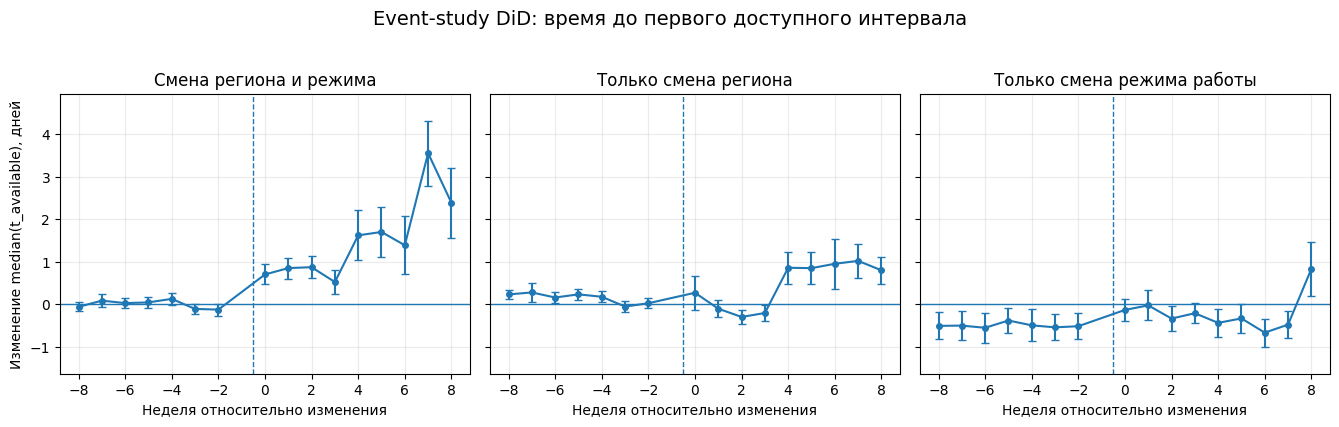

Сохранено: <PROJECT_ROOT>/…


In [8]:
# ============================================================
# 7. График event-study для t_available
# ============================================================

fig, axes = plt.subplots(1, len(TYPE_ORDER), figsize=(13.5, 4.1), sharey=True)

lows, highs = [], []
for ctype in TYPE_ORDER:
    coefs = speed_results.get(ctype, {}).get("coefs")
    if coefs is not None and not coefs.empty:
        lows.extend(coefs["ci_low"].dropna().tolist())
        highs.extend(coefs["ci_high"].dropna().tolist())

y_lim = None
if lows and highs:
    y_min, y_max = min(lows), max(highs)
    pad = 0.12 * (y_max - y_min if y_max > y_min else 0.05)
    y_lim = (y_min - pad, y_max + pad)

for ax, ctype in zip(axes, TYPE_ORDER):
    item = speed_results.get(ctype, {})
    coefs = item.get("coefs")

    ax.axhline(0, linewidth=1.0)
    ax.axvline(-0.5, linestyle="--", linewidth=1.0)

    if coefs is not None and not coefs.empty:
        plot_df = coefs.dropna(subset=["coef", "ci_low", "ci_high"]).copy()
        x = plot_df.index.to_numpy()
        y = plot_df["coef"].to_numpy()
        yerr = np.vstack([
            y - plot_df["ci_low"].to_numpy(),
            plot_df["ci_high"].to_numpy() - y,
        ])
        ax.errorbar(x, y, yerr=yerr, fmt="o-", linewidth=1.5, markersize=4, capsize=3)
    else:
        ax.text(0.5, 0.5, "Нет оценки", ha="center", va="center", transform=ax.transAxes)

    ax.set_title(TYPE_LABELS[ctype])
    ax.set_xlabel("Неделя относительно изменения")
    ax.grid(True, alpha=0.25)
    if y_lim is not None:
        ax.set_ylim(y_lim)

axes[0].set_ylabel("Изменение median(t_available), дней")

fig.suptitle("Event-study DiD: время до первого доступного интервала", y=1.03, fontsize=14)
fig.tight_layout()

out_path = FIG_DIR / "event_study_t_available_by_type_revised.pdf"
fig.savefig(out_path, bbox_inches="tight")
plt.show()

print("Сохранено:", out_path)


## Вывод

Дополнительно была проведена событийная модель DiD-диагностика для временной метрики `t_available`, отражающей время до первого доступного интервала доставки. Оценка выполнялась отдельно для трёх CORE-типов изменений:

1. одновременная смена региона и режима работы;
2. только смена региона;
3. только смена режима работы.

В отличие от бинарных конверсионных метрик, `t_available` агрегировалась на уровне `hex`--день медианой, поскольку временные показатели чувствительны к выбросам.

Результаты показывают, что для всех трёх типов изменений предпосылка параллельных трендов не выполняется. Совместный тест коэффициентов предпериода отвергает отсутствие предтрендов:

* для одновременной смены региона и режима работы: $p < 0.001$;
* для смены только региона: $p < 0.001$;
* для смены только режима работы: $p = 0.011$.

Формально средние post-коэффициенты составляют:

| Тип изменения                 | Средний post-коэффициент, дней | Эквивалент, часов |
| ----------------------------- | -----------------------------: | ----------------: |
| Смена региона и режима работы |                       $+1.512$ |          $+36.29$ |
| Только смена региона          |                       $+0.460$ |          $+11.04$ |
| Только смена режима работы    |                       $-0.200$ |           $-4.80$ |

Следовательно, для изменений региона и одновременных изменений региона и режима работы наблюдаемая динамика указывает на увеличение времени до первого доступного интервала. Для смены только режима работы знак оценки, напротив, отрицательный.

Однако эти значения не интерпретируются как надёжные причинные эффекты, поскольку значимые предтренды показывают, что гексагоны воздействия и контроля уже до воздействия двигались по разным траекториям. Поэтому результаты по `t_available` используются только как диагностическое описание динамики скорости доставки и не включаются в основную таблицу каузальных DiD-результатов.
